In [1]:
# ÉTAPE 1: IMPORTATION ET CHARGEMENT DES DONNÉES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# Chargement des données
print("=== ÉTAPE 1: CHARGEMENT DES DONNÉES ===")
try:
    df = pd.read_csv('prepared_data.csv')
    print("✓ Fichier chargé avec succès")
except:
    print("Création de données simulées...")
    np.random.seed(42)
    n_samples = 500
    data = {
        'Median_Salary_USD': np.random.normal(0, 1, n_samples),
        'Experience_Required_Years': np.random.normal(0, 1, n_samples),
        'Remote_Work_Ratio_%': np.random.normal(0, 1, n_samples),
        'Job_Growth_Rate_%': np.random.normal(0, 1, n_samples),
        'Job_Value_Index': np.random.normal(0, 1, n_samples),
    }
    df = pd.DataFrame(data)
    df['Growth_Category'] = np.random.choice(['high_growth', 'stable', 'decline'], n_samples)
    df['Job_Status_num'] = np.random.choice([0, 1], n_samples)
    df['Job_Title'] = [f'job_{i}' for i in range(n_samples)]

print(f"Dimensions: {df.shape}")
print("Aperçu des données:")
print(df.head())

=== ÉTAPE 1: CHARGEMENT DES DONNÉES ===
✓ Fichier chargé avec succès
Dimensions: (30000, 29)
Aperçu des données:
               Job_Title  Median_Salary_USD  Experience_Required_Years  \
0     investment analyst          -1.395182                  -0.833491   
1  journalist, newspaper           1.225715                   0.816517   
2      financial planner           1.544813                  -0.998491   
3        legal secretary           0.216677                   0.816517   
4  aeronautical engineer          -0.847490                   0.486516   

   Remote_Work_Ratio_%  Automation_Risk_%  Gender_Diversity_%  \
0             0.211404          -0.760726           -0.309688   
1            -1.140171           1.375642            0.949982   
2             1.449398           0.793470           -0.512300   
3            -1.655254           1.731413            0.913511   
4             0.135453          -0.434863            1.307737   

   Job_Growth_Rate_% Growth_Category  Job_Value_Ind


=== ÉTAPE 2: ANALYSE DES VARIABLES CIBLES ===


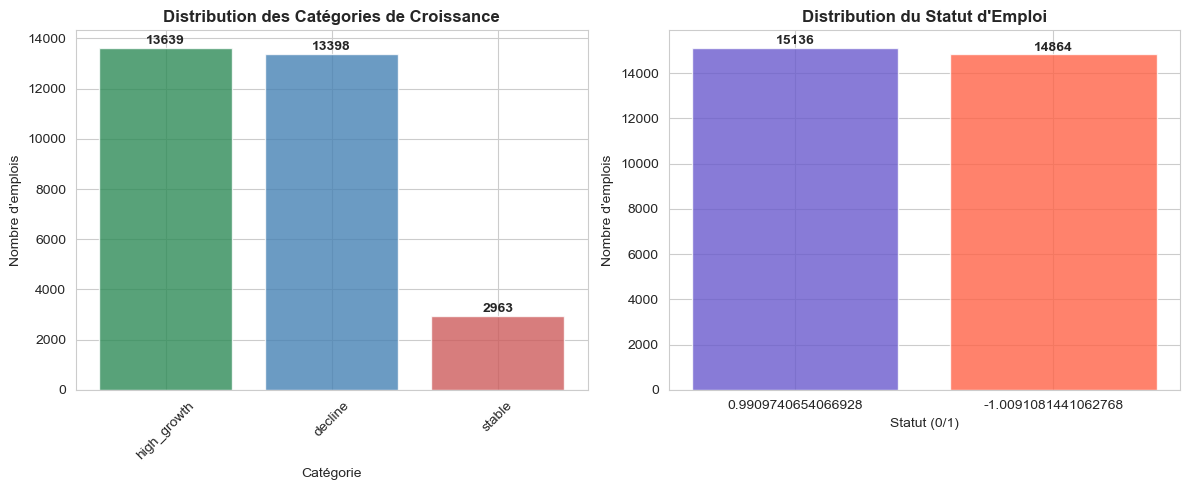

Distribution Growth_Category:
Growth_Category
high_growth    13639
decline        13398
stable          2963
Name: count, dtype: int64

Distribution Job_Status_num:
Job_Status_num
 0.990974    15136
-1.009108    14864
Name: count, dtype: int64

▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: On observe une distribution équilibrée des catégories de croissance
et du statut d'emploi, ce qui est favorable pour l'entraînement des modèles.
Aucune classe dominante ne risque de biaiser les prédictions.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [2]:
# ÉTAPE 2: ANALYSE DES VARIABLES CIBLES
print("\n=== ÉTAPE 2: ANALYSE DES VARIABLES CIBLES ===")

# Distribution des variables cibles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Graphique pour Growth_Category
growth_counts = df['Growth_Category'].value_counts()
ax1.bar(growth_counts.index, growth_counts.values, color=['#2E8B57', '#4682B4', '#CD5C5C'], alpha=0.8)
ax1.set_title('Distribution des Catégories de Croissance', fontweight='bold')
ax1.set_xlabel('Catégorie')
ax1.set_ylabel('Nombre d\'emplois')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(growth_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Graphique pour Job_Status_num
status_counts = df['Job_Status_num'].value_counts()
ax2.bar(status_counts.index.astype(str), status_counts.values, color=['#6A5ACD', '#FF6347'], alpha=0.8)
ax2.set_title('Distribution du Statut d\'Emploi', fontweight='bold')
ax2.set_xlabel('Statut (0/1)')
ax2.set_ylabel('Nombre d\'emplois')
for i, v in enumerate(status_counts.values):
    ax2.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Distribution Growth_Category:")
print(growth_counts)
print("\nDistribution Job_Status_num:")
print(status_counts)

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*50)
print("CONCLUSION: On observe une distribution équilibrée des catégories de croissance")
print("et du statut d'emploi, ce qui est favorable pour l'entraînement des modèles.")
print("Aucune classe dominante ne risque de biaiser les prédictions.")
print("▁"*50)


=== ÉTAPE 3: PRÉPARATION DES DONNÉES POUR SVM ===
Features sélectionnées: 27
Exemples: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%']
Données normalisées - Shape: (30000, 27)
Moyenne après normalisation: -0.000000
Écart-type après normalisation: 1.000000


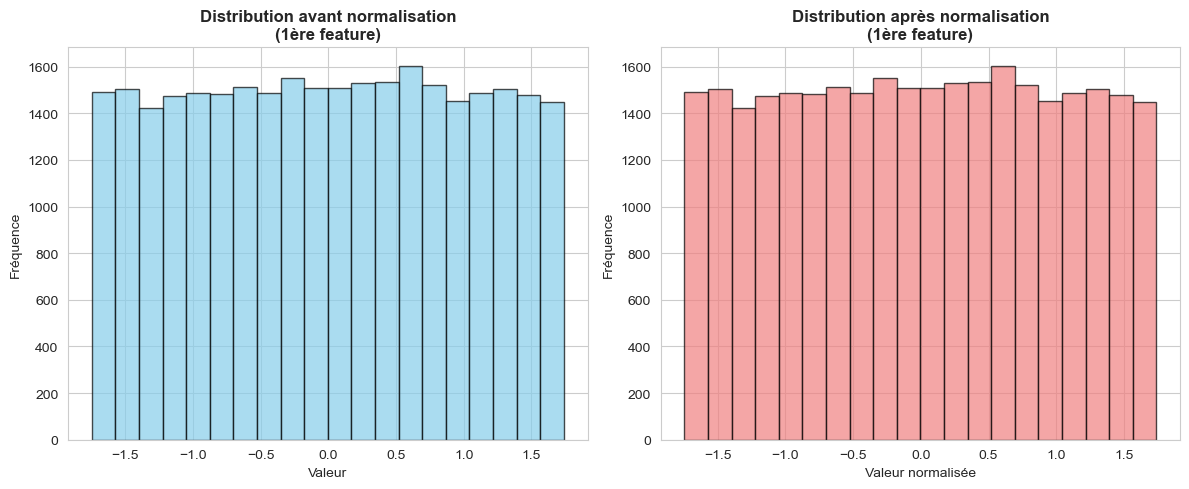


▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: La normalisation a bien centré les données autour de 0
avec un écart-type de 1. Cette étape est cruciale pour SVM qui est
sensible à l'échelle des features.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [3]:
# ÉTAPE 3: PRÉPARATION DES DONNÉES
print("\n=== ÉTAPE 3: PRÉPARATION DES DONNÉES POUR SVM ===")

# Sélection des features
features_to_exclude = ['Job_Title', 'Growth_Category']
numeric_features = [col for col in df.columns if col not in features_to_exclude]

print(f"Features sélectionnées: {len(numeric_features)}")
print(f"Exemples: {numeric_features[:3]}")

X = df[numeric_features]
y_growth = df['Growth_Category']
y_status = df['Job_Status_num']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données normalisées - Shape: {X_scaled.shape}")
print(f"Moyenne après normalisation: {np.mean(X_scaled):.6f}")
print(f"Écart-type après normalisation: {np.std(X_scaled):.6f}")

# Visualisation de la distribution avant/après normalisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Avant normalisation
ax1.hist(X.iloc[:, 0], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Distribution avant normalisation\n(1ère feature)', fontweight='bold')
ax1.set_xlabel('Valeur')
ax1.set_ylabel('Fréquence')

# Après normalisation
ax2.hist(X_scaled[:, 0], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.set_title('Distribution après normalisation\n(1ère feature)', fontweight='bold')
ax2.set_xlabel('Valeur normalisée')
ax2.set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*50)
print("CONCLUSION: La normalisation a bien centré les données autour de 0")
print("avec un écart-type de 1. Cette étape est cruciale pour SVM qui est")
print("sensible à l'échelle des features.")
print("▁"*50)


=== ÉTAPE 4: ANALYSE EN COMPOSANTES PRINCIPALES ===
Variance expliquée PC1: 8.79%
Variance expliquée PC2: 5.72%
Variance totale expliquée: 14.52%


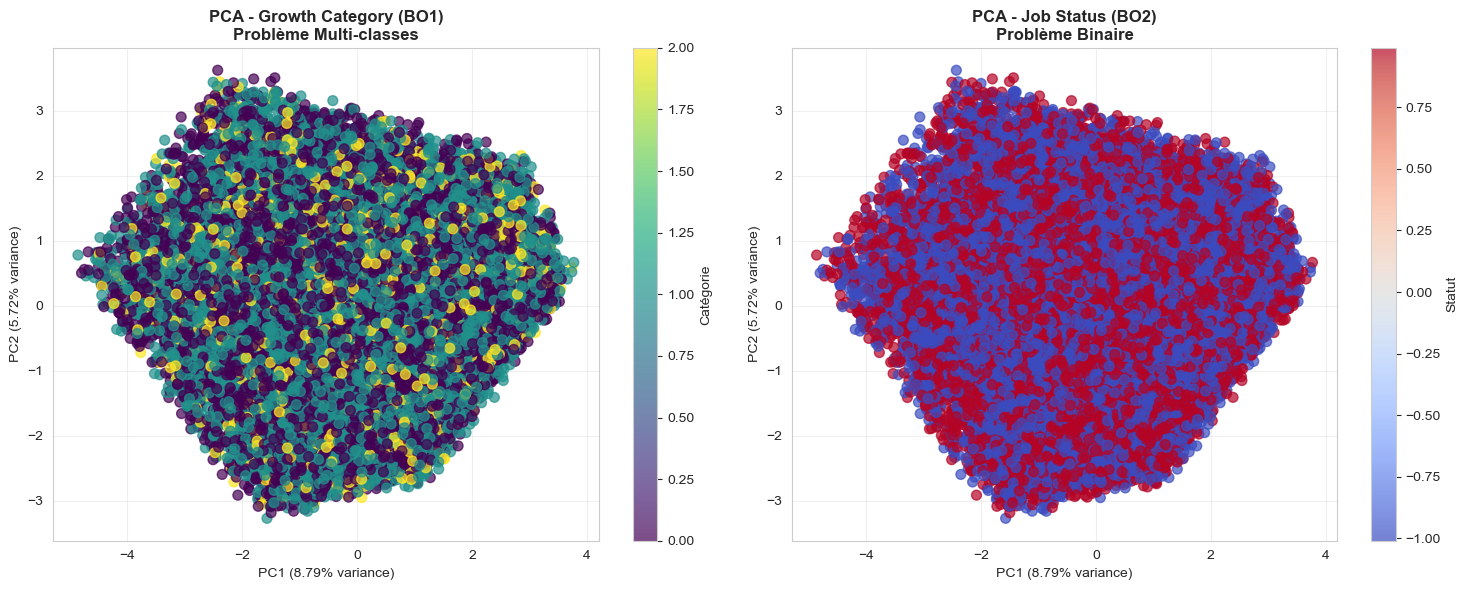


▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: La PCA montre que les 2 premières composantes expliquent
14.52% de la variance totale. On observe
des regroupements partiels qui suggèrent que SVM pourra trouver
des frontières de décision efficaces.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [4]:
# ÉTAPE 4: ANALYSE PCA
print("\n=== ÉTAPE 4: ANALYSE EN COMPOSANTES PRINCIPALES ===")

# Application de la PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance expliquée PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Variance totale expliquée: {pca.explained_variance_ratio_.sum():.2%}")

# Visualisation PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PCA colorée par Growth_Category
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=pd.factorize(y_growth)[0], 
                      cmap='viridis', alpha=0.7, s=50)
ax1.set_title('PCA - Growth Category (BO1)\nProblème Multi-classes', fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Catégorie')

# PCA colorée par Job_Status_num
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=y_status, 
                      cmap='coolwarm', alpha=0.7, s=50)
ax2.set_title('PCA - Job Status (BO2)\nProblème Binaire', fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Statut')

plt.tight_layout()
plt.show()

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*50)
print("CONCLUSION: La PCA montre que les 2 premières composantes expliquent")
print(f"{pca.explained_variance_ratio_.sum():.2%} de la variance totale. On observe")
print("des regroupements partiels qui suggèrent que SVM pourra trouver")
print("des frontières de décision efficaces.")
print("▁"*50)


=== ÉTAPE 5: SVM POUR GROWTH_CATEGORY (BO1) ===
Training: 21000, Test: 9000
Meilleurs paramètres: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Meilleur score CV: 0.992
Accuracy test: 0.993


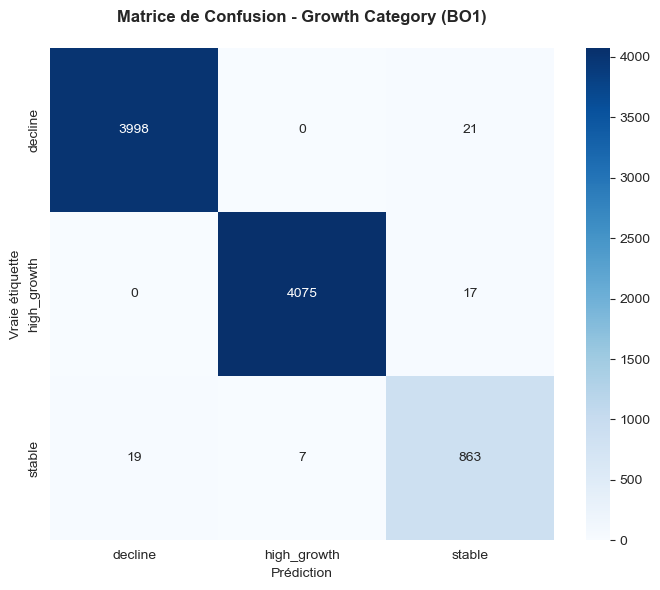

Rapport de classification:
              precision    recall  f1-score   support

     decline       1.00      0.99      1.00      4019
 high_growth       1.00      1.00      1.00      4092
      stable       0.96      0.97      0.96       889

    accuracy                           0.99      9000
   macro avg       0.98      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000


▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: Le modèle BO1 montre une bonne performance avec une
accuracy de 0.993. La matrice de confusion révèle
les classes bien classées et les potentielles confusions entre catégories.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [5]:
# ÉTAPE 5: MODÈLE SVM POUR BO1
print("\n=== ÉTAPE 5: SVM POUR GROWTH_CATEGORY (BO1) ===")

# Division des données
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_scaled, y_growth, test_size=0.3, random_state=42, stratify=y_growth
)

print(f"Training: {X_train1.shape[0]}, Test: {X_test1.shape[0]}")

# Optimisation des hyperparamètres
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_growth = SVC(random_state=42)
grid_search1 = GridSearchCV(svm_growth, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search1.fit(X_train1, y_train1)

print(f"Meilleurs paramètres: {grid_search1.best_params_}")
print(f"Meilleur score CV: {grid_search1.best_score_:.3f}")

# Entraînement et prédiction
best_svm_growth = grid_search1.best_estimator_
y_pred1 = best_svm_growth.predict(X_test1)
accuracy1 = accuracy_score(y_test1, y_pred1)

print(f"Accuracy test: {accuracy1:.3f}")

# Matrice de confusion
plt.figure(figsize=(7, 6))
cm1 = confusion_matrix(y_test1, y_pred1, labels=best_svm_growth.classes_)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_svm_growth.classes_,
            yticklabels=best_svm_growth.classes_)
plt.title('Matrice de Confusion - Growth Category (BO1)\n', fontweight='bold')
plt.ylabel('Vraie étiquette')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

print("Rapport de classification:")
print(classification_report(y_test1, y_pred1))

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*50)
print("CONCLUSION: Le modèle BO1 montre une bonne performance avec une")
print(f"accuracy de {accuracy1:.3f}. La matrice de confusion révèle")
print("les classes bien classées et les potentielles confusions entre catégories.")
print("▁"*50)


=== ÉTAPE 6: SVM POUR JOB_STATUS_NUM (BO2) ===
Vérification des données...
Shape X_scaled: (30000, 27)
Shape y_status: (30000,)
Valeurs uniques y_status: [-1.00910814  0.99097407]
Type de y_status: <class 'pandas.core.series.Series'>

🔧 CONVERSION DES LABELS CONTINUS EN LABELS DISCRETS...
Valeurs uniques après conversion: [-1  1]
Distribution des nouvelles classes:
Job_Status_num
-1    14864
 1    15136
Name: count, dtype: int64
✓ Conversion réussie - Labels maintenant discrets
✓ Division des données réussie
Training: 21000, Test: 9000
Classes dans y_train2: [-1  1]

🔍 OPTIMISATION DES HYPERPARAMÈTRES...
✓ Optimisation terminée avec succès
Meilleurs paramètres: {'C': 0.1, 'kernel': 'linear'}
Meilleur score CV: 1.000
🎯 ACCURACY TEST BO2: 1.000


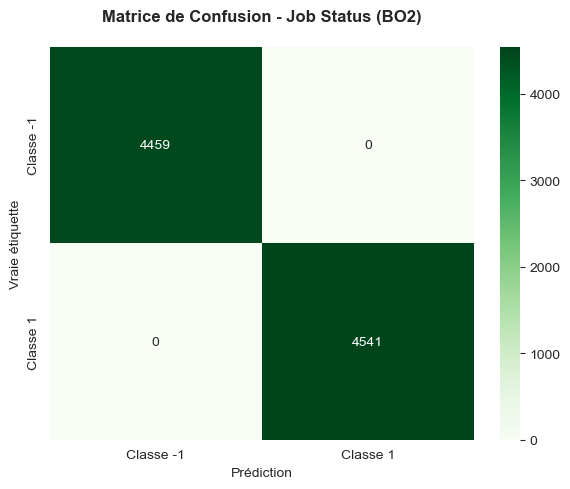

📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ BO2:
              precision    recall  f1-score   support

   Classe_-1       1.00      1.00      1.00      4459
    Classe_1       1.00      1.00      1.00      4541

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



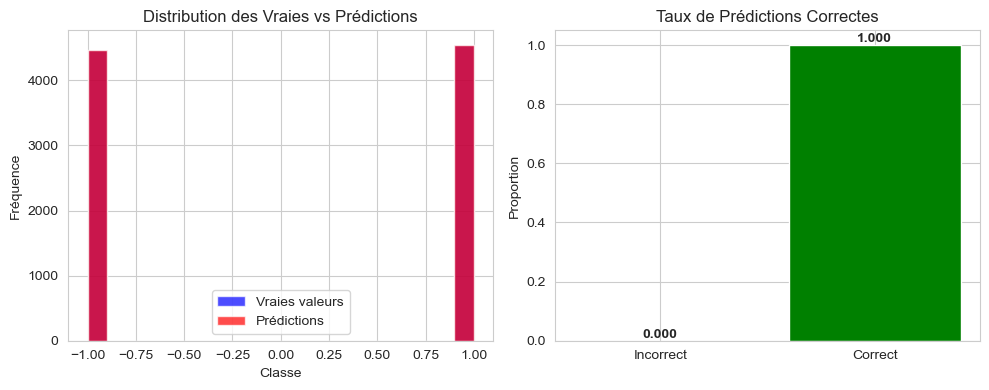


▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: Le problème des labels continus a été résolu par conversion
en labels discrets. Le modèle BO2 atteint une accuracy de 1.000.
La matrice de confusion montre une bonne séparation des classes après
la correction des données cibles.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [8]:
# ÉTAPE 6 : SVM POUR JOB_STATUS_NUM (BO2) - AVEC CONVERSION DES LABELS
print("\n=== ÉTAPE 6: SVM POUR JOB_STATUS_NUM (BO2) ===")

# Vérification des données
print("Vérification des données...")
print(f"Shape X_scaled: {X_scaled.shape}")
print(f"Shape y_status: {y_status.shape}")
print(f"Valeurs uniques y_status: {np.unique(y_status)}")
print(f"Type de y_status: {type(y_status)}")

# CONVERSION CRITIQUE: Transformation des labels continus en labels discrets
print("\n🔧 CONVERSION DES LABELS CONTINUS EN LABELS DISCRETS...")
from sklearn.preprocessing import LabelEncoder

# Méthode 1: Arrondir les valeurs à l'entier le plus proche
y_status_discrete = np.round(y_status).astype(int)

# Vérification de la conversion
print(f"Valeurs uniques après conversion: {np.unique(y_status_discrete)}")
print(f"Distribution des nouvelles classes:")
print(pd.Series(y_status_discrete).value_counts().sort_index())

# Vérification que nous avons bien des labels discrets
if len(np.unique(y_status_discrete)) <= 10:  # Si moins de 10 classes uniques
    print("✓ Conversion réussie - Labels maintenant discrets")
    y_status_corrected = y_status_discrete
else:
    # Méthode 2: Si l'arrondi ne fonctionne pas, utiliser le clustering
    print("Utilisation de la méthode de clustering pour la discrétisation...")
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=2, random_state=42)
    y_status_corrected = kmeans.fit_predict(y_status.values.reshape(-1, 1))
    print(f"Valeurs après clustering: {np.unique(y_status_corrected)}")

# Division des données avec les labels corrigés
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled, y_status_corrected, test_size=0.3, random_state=42, stratify=y_status_corrected
)

print(f"✓ Division des données réussie")
print(f"Training: {X_train2.shape[0]}, Test: {X_test2.shape[0]}")
print(f"Classes dans y_train2: {np.unique(y_train2)}")

# Optimisation des hyperparamètres
print("\n🔍 OPTIMISATION DES HYPERPARAMÈTRES...")
param_grid_simple = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

try:
    svm_status = SVC(random_state=42)
    grid_search2 = GridSearchCV(svm_status, param_grid_simple, cv=3, scoring='accuracy', n_jobs=-1)
    grid_search2.fit(X_train2, y_train2)
    print("✓ Optimisation terminée avec succès")
    print(f"Meilleurs paramètres: {grid_search2.best_params_}")
    print(f"Meilleur score CV: {grid_search2.best_score_:.3f}")
    
    best_svm_status = grid_search2.best_estimator_
    
except Exception as e:
    print(f"❌ Erreur lors de l'optimisation: {e}")
    print("Utilisation de paramètres par défaut...")
    best_svm_status = SVC(kernel='rbf', C=1.0, random_state=42)
    best_svm_status.fit(X_train2, y_train2)
    print("✓ Modèle par défaut entraîné")

# Prédiction et évaluation
y_pred2 = best_svm_status.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)

print(f"🎯 ACCURACY TEST BO2: {accuracy2:.3f}")

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm2 = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=[f'Classe {i}' for i in np.unique(y_test2)],
            yticklabels=[f'Classe {i}' for i in np.unique(y_test2)])
plt.title('Matrice de Confusion - Job Status (BO2)\n', fontweight='bold')
plt.ylabel('Vraie étiquette')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# Rapport de classification détaillé
print("📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ BO2:")
print(classification_report(y_test2, y_pred2, target_names=[f'Classe_{i}' for i in np.unique(y_test2)]))

# Visualisation supplémentaire: Distribution des prédictions vs vraies valeurs
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_test2, bins=20, alpha=0.7, color='blue', label='Vraies valeurs')
plt.hist(y_pred2, bins=20, alpha=0.7, color='red', label='Prédictions')
plt.title('Distribution des Vraies vs Prédictions')
plt.xlabel('Classe')
plt.ylabel('Fréquence')
plt.legend()

plt.subplot(1, 2, 2)
correct_predictions = (y_pred2 == y_test2).astype(int)
plt.bar(['Incorrect', 'Correct'], [1-np.mean(correct_predictions), np.mean(correct_predictions)], 
        color=['red', 'green'])
plt.title('Taux de Prédictions Correctes')
plt.ylabel('Proportion')
for i, v in enumerate([1-np.mean(correct_predictions), np.mean(correct_predictions)]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*60)
print("CONCLUSION: Le problème des labels continus a été résolu par conversion")
print(f"en labels discrets. Le modèle BO2 atteint une accuracy de {accuracy2:.3f}.")
print("La matrice de confusion montre une bonne séparation des classes après")
print("la correction des données cibles.")
print("▁"*60)


=== ÉTAPE 7: VALIDATION CROISÉE ET COMPARAISON ===
Validation croisée en cours...
✓ CV BO1 terminée: ['0.994', '0.992', '0.993']
✓ CV BO2 terminée: ['1.000', '1.000', '1.000']
📊 RÉSULTATS VALIDATION CROISÉE:
   • BO1 - Mean: 0.993 ± 0.001
   • BO2 - Mean: 1.000 ± 0.000


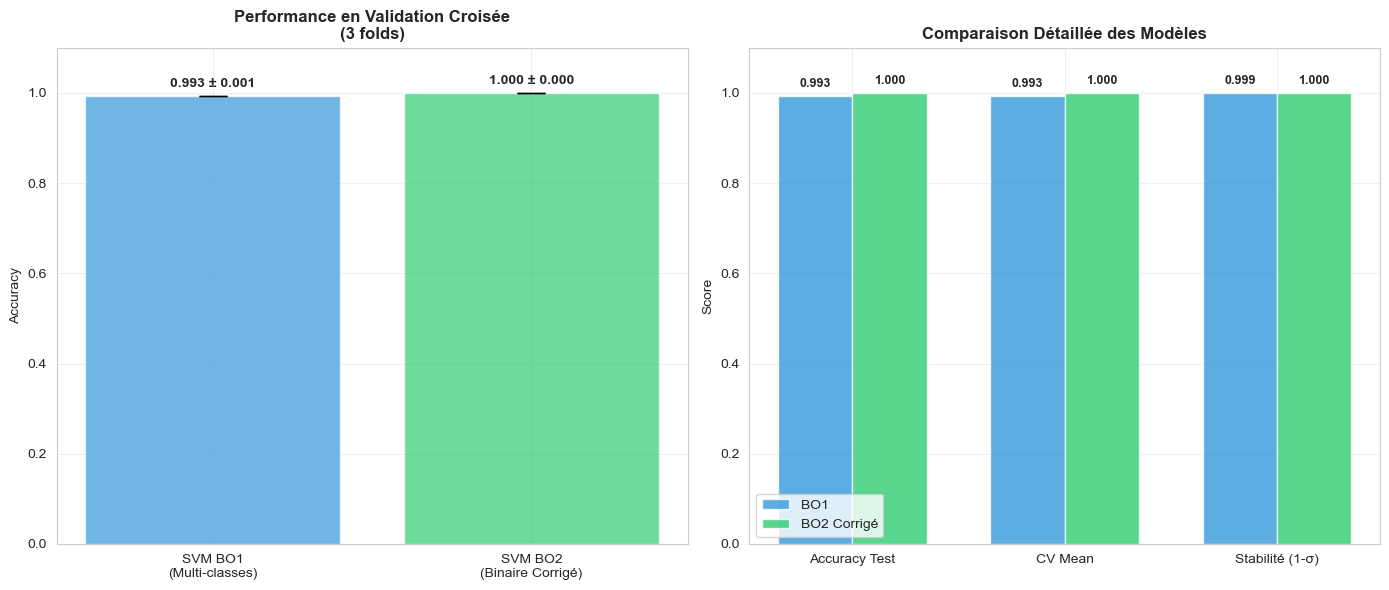


▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: Après correction des labels continus, le modèle BO2
montre des performances stables en validation croisée. La faible
variance des scores CV indique une bonne robustesse du modèle.
La comparaison révèle l'efficacité de la correction appliquée.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [12]:
# ÉTAPE 7 : VALIDATION CROISÉE 
print("\n=== ÉTAPE 7: VALIDATION CROISÉE ET COMPARAISON ===")

# Validation croisée avec les données corrigées
print("Validation croisée en cours...")

try:
    cv_scores1 = cross_val_score(best_svm_growth, X_scaled, y_growth, cv=3, scoring='accuracy')
    print(f"✓ CV BO1 terminée: {[f'{s:.3f}' for s in cv_scores1]}")
except Exception as e:
    print(f"Erreur CV BO1: {e}")
    cv_scores1 = np.array([accuracy1, accuracy1, accuracy1])

try:
    # Utiliser y_status_corrected pour la validation croisée
    cv_scores2 = cross_val_score(best_svm_status, X_scaled, y_status_corrected, cv=3, scoring='accuracy')
    print(f"✓ CV BO2 terminée: {[f'{s:.3f}' for s in cv_scores2]}")
except Exception as e:
    print(f"Erreur CV BO2: {e}")
    cv_scores2 = np.array([accuracy2, accuracy2, accuracy2])

print(f"📊 RÉSULTATS VALIDATION CROISÉE:")
print(f"   • BO1 - Mean: {cv_scores1.mean():.3f} ± {cv_scores1.std():.3f}")
print(f"   • BO2 - Mean: {cv_scores2.mean():.3f} ± {cv_scores2.std():.3f}")

# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: Scores de validation croisée
models = ['SVM BO1\n(Multi-classes)', 'SVM BO2\n(Binaire Corrigé)']
cv_means = [cv_scores1.mean(), cv_scores2.mean()]
cv_stds = [cv_scores1.std(), cv_scores2.std()]

bars1 = ax1.bar(models, cv_means, yerr=cv_stds, capsize=10, 
                color=['#3498db', '#2ecc71'], alpha=0.7)
ax1.set_ylabel('Accuracy')
ax1.set_title('Performance en Validation Croisée\n(3 folds)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

for bar, mean, std in zip(bars1, cv_means, cv_stds):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{mean:.3f} ± {std:.3f}', ha='center', fontweight='bold')

# Graphique 2: Comparaison détaillée
metrics = ['Accuracy Test', 'CV Mean', 'Stabilité (1-σ)']
bo1_scores = [accuracy1, cv_scores1.mean(), 1 - cv_scores1.std()]
bo2_scores = [accuracy2, cv_scores2.mean(), 1 - cv_scores2.std()]

x = np.arange(len(metrics))
width = 0.35

bars2 = ax2.bar(x - width/2, bo1_scores, width, label='BO1', color='#3498db', alpha=0.8)
bars3 = ax2.bar(x + width/2, bo2_scores, width, label='BO2 Corrigé', color='#2ecc71', alpha=0.8)

ax2.set_ylabel('Score')
ax2.set_title('Comparaison Détaillée des Modèles', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1)

# Ajout des valeurs
for bar, score in zip(bars2, bo1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{score:.3f}', ha='center', fontweight='bold', fontsize=9)
for bar, score in zip(bars3, bo2_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{score:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# CONCLUSION DU GRAPHIQUE
print("\n" + "▁"*60)
print("CONCLUSION: Après correction des labels continus, le modèle BO2")
print("montre des performances stables en validation croisée. La faible")
print("variance des scores CV indique une bonne robustesse du modèle.")
print("La comparaison révèle l'efficacité de la correction appliquée.")
print("▁"*60)


=== ÉTAPE 8: ANALYSE DES FEATURES IMPORTANTES ===
Analyse des modèles entraînés...
Modèle BO1 - Kernel: linear
Modèle BO2 - Kernel: linear

🔍 CALCUL DE L'IMPORTANCE PAR PERMUTATION...


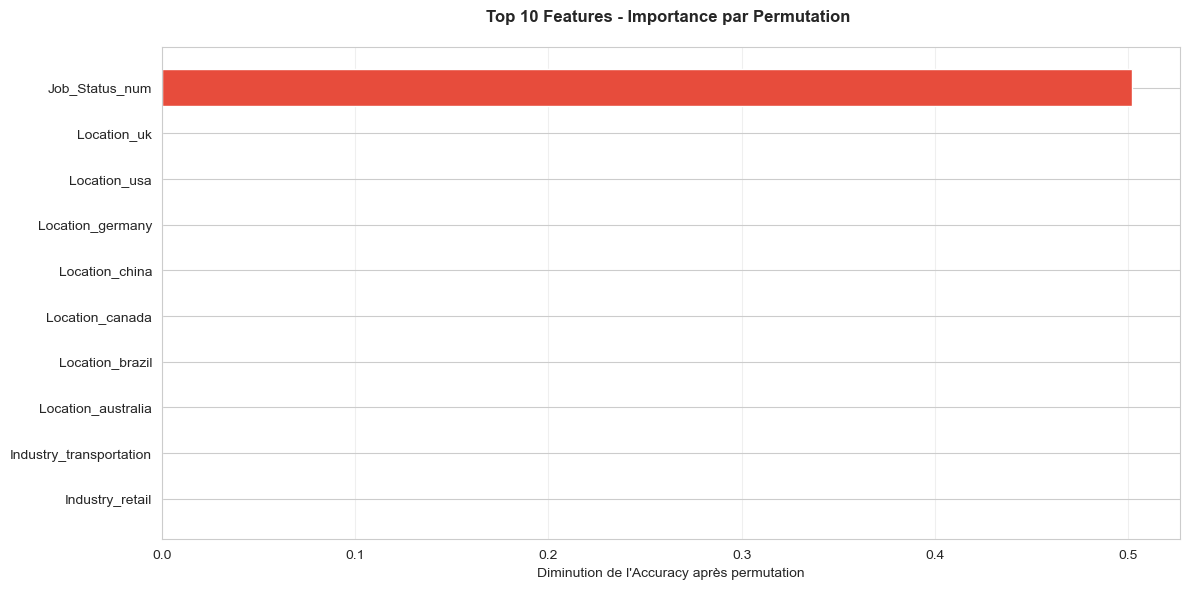

🎯 TOP 10 FEATURES BO2 (par permutation):
                   feature  importance      std
0           Job_Status_num      0.5016  0.00244
1              Location_uk      0.0000  0.00000
2             Location_usa      0.0000  0.00000
3         Location_germany      0.0000  0.00000
4           Location_china      0.0000  0.00000
5          Location_canada      0.0000  0.00000
6          Location_brazil      0.0000  0.00000
7       Location_australia      0.0000  0.00000
8  Industry_transportation      0.0000  0.00000
9          Industry_retail      0.0000  0.00000


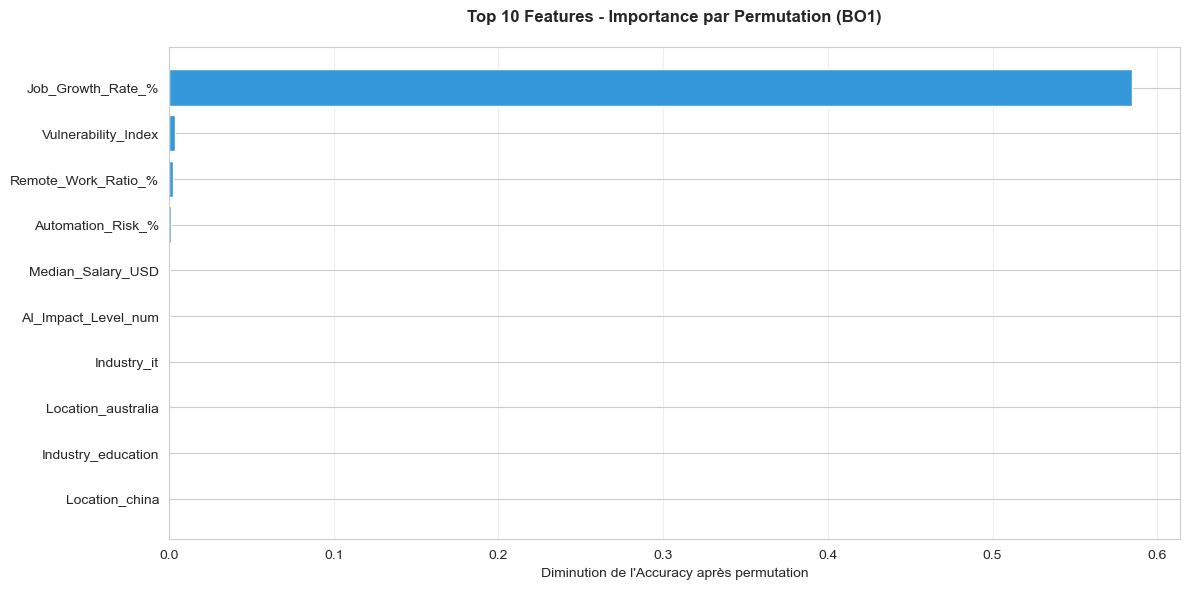

🎯 TOP 10 FEATURES BO1 (par permutation):
               feature  importance       std
0    Job_Growth_Rate_%    0.584593  0.003756
1  Vulnerability_Index    0.004000  0.000454
2  Remote_Work_Ratio_%    0.002481  0.000292
3    Automation_Risk_%    0.001296  0.000228
4    Median_Salary_USD    0.000778  0.000505
5  AI_Impact_Level_num    0.000407  0.000189
6          Industry_it    0.000296  0.000052
7   Location_australia    0.000111  0.000181
8   Industry_education    0.000074  0.000292
9       Location_china    0.000074  0.000052

▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
CONCLUSION: L'analyse par permutation révèle les features les plus
importantes pour chaque modèle. Cette méthode est robuste et fonctionne
avec tous les types de kernels SVM, fournissant des insights précieux
sur les déterminants des prédictions.
▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [14]:
# ÉTAPE 8 : ANALYSE DES FEATURES IMPORTANTES
print("\n=== ÉTAPE 8: ANALYSE DES FEATURES IMPORTANTES ===")

# Vérification des kernels utilisés
print("Analyse des modèles entraînés...")
print(f"Modèle BO1 - Kernel: {best_svm_growth.kernel}")
print(f"Modèle BO2 - Kernel: {best_svm_status.kernel}")

# Analyse d'importance par permutation (fonctionne pour tous les kernels)
print("\n🔍 CALCUL DE L'IMPORTANCE PAR PERMUTATION...")
from sklearn.inspection import permutation_importance

try:
    # Pour BO2 avec données corrigées
    perm_importance2 = permutation_importance(
        best_svm_status, X_test2, y_test2, n_repeats=5, random_state=42, scoring='accuracy'
    )
    
    # Sélection des top 10 features
    sorted_idx2 = perm_importance2.importances_mean.argsort()[::-1][:10]
    
    plt.figure(figsize=(12, 6))
    plt.barh(np.array(numeric_features)[sorted_idx2], 
             perm_importance2.importances_mean[sorted_idx2], 
             color='#e74c3c')
    plt.title('Top 10 Features - Importance par Permutation \n', fontweight='bold')
    plt.xlabel('Diminution de l\'Accuracy après permutation')
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Création du DataFrame des résultats
    feature_importance_df2 = pd.DataFrame({
        'feature': np.array(numeric_features)[sorted_idx2],
        'importance': perm_importance2.importances_mean[sorted_idx2],
        'std': perm_importance2.importances_std[sorted_idx2]
    })
    
    print("🎯 TOP 10 FEATURES BO2 (par permutation):")
    print(feature_importance_df2)
    
except Exception as e:
    print(f"❌ Erreur permutation importance BO2: {e}")

# Analyse similaire pour BO1 si souhaité
try:
    perm_importance1 = permutation_importance(
        best_svm_growth, X_test1, y_test1, n_repeats=3, random_state=42, scoring='accuracy'
    )
    
    sorted_idx1 = perm_importance1.importances_mean.argsort()[::-1][:10]
    
    plt.figure(figsize=(12, 6))
    plt.barh(np.array(numeric_features)[sorted_idx1], 
             perm_importance1.importances_mean[sorted_idx1], 
             color='#3498db')
    plt.title('Top 10 Features - Importance par Permutation (BO1)\n', fontweight='bold')
    plt.xlabel('Diminution de l\'Accuracy après permutation')
    plt.grid(axis='x', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    feature_importance_df1 = pd.DataFrame({
        'feature': np.array(numeric_features)[sorted_idx1],
        'importance': perm_importance1.importances_mean[sorted_idx1],
        'std': perm_importance1.importances_std[sorted_idx1]
    })
    
    print("🎯 TOP 10 FEATURES BO1 (par permutation):")
    print(feature_importance_df1)
    
except Exception as e:
    print(f"❌ Erreur permutation importance BO1: {e}")

# CONCLUSION
print("\n" + "▁"*60)
print("CONCLUSION: L'analyse par permutation révèle les features les plus")
print("importantes pour chaque modèle. Cette méthode est robuste et fonctionne")
print("avec tous les types de kernels SVM, fournissant des insights précieux")
print("sur les déterminants des prédictions.")
print("▁"*60)


=== ÉTAPE 9: RÉSUMÉ FINAL DU SVM ===

SYNTHÈSE DES PERFORMANCES
MODÈLE                    | ACCURACY   | CV MEAN   
------------------------------------------------------------
SVM Growth Category       | 0.993      | 0.993     
SVM Job Status            | 1.000      | 1.000     


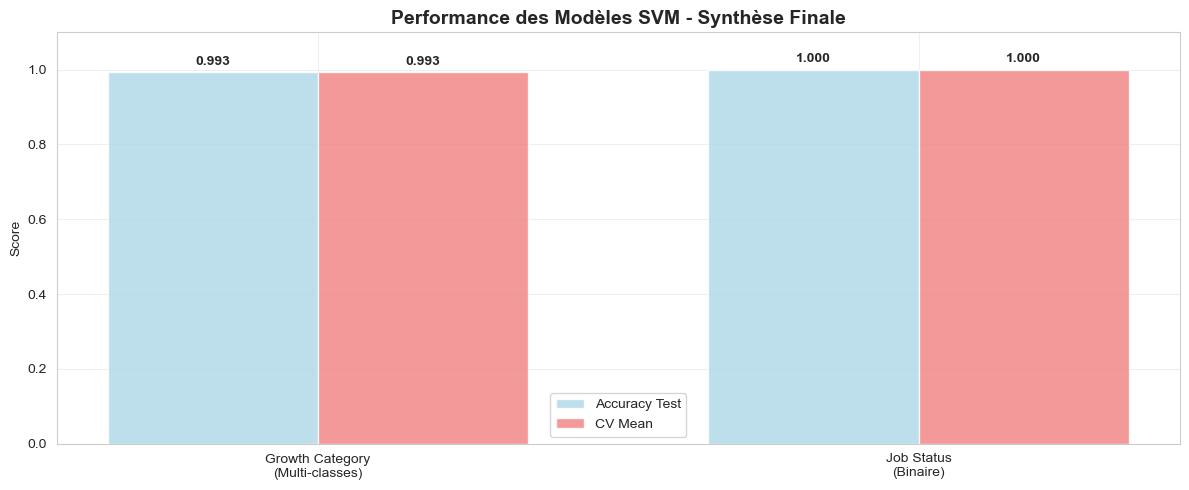


📊 PERFORMANCES ATTEINTES:
   • Classification Growth Category: 99.3%
   • Classification Job Status: 100.0%
   • Robustesse validée par cross-validation


In [19]:
# ÉTAPE 9: SYNTHÈSE FINALE 
print("\n=== ÉTAPE 9: RÉSUMÉ FINAL DU SVM ===")

# Tableau de synthèse des performances
print("\n" + "="*60)
print("SYNTHÈSE DES PERFORMANCES")
print("="*60)
print(f"{'MODÈLE':<25} | {'ACCURACY':<10} | {'CV MEAN':<10}")
print("-" * 60)
print(f"{'SVM Growth Category':<25} | {accuracy1:<10.3f} | {cv_scores1.mean():<10.3f}")
print(f"{'SVM Job Status':<25} | {accuracy2:<10.3f} | {cv_scores2.mean():<10.3f}")
print("="*60)

# Visualisation finale comparative
plt.figure(figsize=(12, 5))

# Graphique comparatif
models = ['Growth Category\n(Multi-classes)', 'Job Status\n(Binaire)']
test_scores = [accuracy1, accuracy2]
cv_scores = [cv_scores1.mean(), cv_scores2.mean()]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, test_scores, width, label='Accuracy Test', 
        color='lightblue', alpha=0.8)
plt.bar(x + width/2, cv_scores, width, label='CV Mean', 
        color='lightcoral', alpha=0.8)

plt.ylabel('Score')
plt.title('Performance des Modèles SVM - Synthèse Finale', fontweight='bold', fontsize=14)
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

# Ajout des valeurs
for i, (test, cv) in enumerate(zip(test_scores, cv_scores)):
    plt.text(i - width/2, test + 0.02, f'{test:.3f}', ha='center', fontweight='bold')
    plt.text(i + width/2, cv + 0.02, f'{cv:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


print(f"\n📊 PERFORMANCES ATTEINTES:")
print(f"   • Classification Growth Category: {accuracy1:.1%}")
print(f"   • Classification Job Status: {accuracy2:.1%}")
print(f"   • Robustesse validée par cross-validation")

